<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


## Resolucion del desafio

Se construye un modelo de lenguaje a nivel de caracteres con tres obras literarias en espanol que ya estan en `Desafio_2/corpus`. El flujo incluye limpieza basica, particion cronologica de entrenamiento y validacion, ventanas de contexto, un modelo recurrente LSTM y generacion con greedy y beam search deterministico y estocastico. Cada bloque de codigo tiene comentarios y las decisiones/resultados se explican en texto.


### 1. Preparacion del corpus

Se leen los archivos disponibles en el repositorio para que la ejecucion no dependa de una conexion externa. Se quitan, cuando estan presentes, la cabecera y el pie de Project Gutenberg, y se pasan los textos a minuscula.


In [4]:
# Importamos las herramientas para leer los textos, preparar secuencias y construir el modelo.
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fijamos semillas para que la inicializacion y las muestras sean mas reproducibles.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Buscamos el corpus tanto si el notebook se ejecuta desde la raiz como desde Desafio_3.
possible_corpus_dirs = [Path("Desafio_2/corpus"), Path("../Desafio_2/corpus")]
CORPUS_DIR = next((path for path in possible_corpus_dirs if path.exists()), None)
if CORPUS_DIR is None:
    raise FileNotFoundError("No se encontro Desafio_2/corpus. Ejecuta el notebook desde la raiz o desde Desafio_3.")

# Elegimos los tres libros que componen el corpus propio del experimento.
CORPUS_FILES = [
    "Don_Quijote.txt",
    "El_libro_de_las_mil_noches_y_una_noche.txt",
    "La_Odisea.txt",
]

def clean_gutenberg(text):
    # Si el archivo incluye marcas de Project Gutenberg, descartamos su texto editorial.
    text = re.sub(r"(?is).*?\*\*\* START OF[^*]*\*\*\*", "", text, count=1)
    text = re.sub(r"(?is)\*\*\* END OF[^*]*\*\*\*.*", "", text, count=1)
    # Normalizamos mayusculas y espacios sin eliminar acentos ni signos de puntuacion.
    return re.sub(r"\s+", " ", text.lower()).strip()

# Leemos y limpiamos cada libro y luego los unimos en un unico flujo de caracteres.
texts = []
for filename in CORPUS_FILES:
    file_path = CORPUS_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f"No se encontro el archivo del corpus: {file_path}")
    texts.append(clean_gutenberg(file_path.read_text(encoding="utf-8", errors="replace")))
article_text = " ".join(texts)
print(f"Libros: {len(texts)} | Caracteres: {len(article_text):,}")

print(tf.config.list_physical_devices("GPU"))


Libros: 3 | Caracteres: 3,436,834
[]


El corpus combina narracion y vocabulario de tres obras de estilos distintos. Esta mezcla permite entrenar un modelo de juguete con suficientes ejemplos, aunque las continuaciones reflejaran esos textos y no el espanol general. La limpieza conserva los caracteres acentuados y los signos, porque tambien son parte de la distribucion que el modelo debe aprender.


### 2. Vocabulario, particion y ventanas

Cada caracter distinto es un token. Se reserva el ultimo 10 % del corpus para validacion, respetando el orden del texto. Las ventanas se mantienen dentro de cada particion para evitar que una secuencia de entrenamiento cruce al tramo de validacion.


In [5]:
# Creamos las conversiones entre caracteres e indices enteros; el orden fijo facilita repetir el resultado.
chars_vocab = sorted(set(article_text))
char2idx = {char: idx for idx, char in enumerate(chars_vocab)}
idx2char = {idx: char for char, idx in char2idx.items()}
vocab_size = len(chars_vocab)
tokenized_text = np.fromiter((char2idx[char] for char in article_text), dtype=np.int32)
print(f"Tamano del vocabulario: {vocab_size} caracteres")

# Separamos cronologicamente el tramo final como validacion.
max_context_size = 100
validation_fraction = 0.10
split_at = int(len(tokenized_text) * (1 - validation_fraction))
train_text = tokenized_text[:split_at]
val_text = tokenized_text[split_at:]

# Convertimos el flujo de cada particion en pares: contexto de 100 caracteres y siguiente caracter.
# El stride reduce ejemplos casi duplicados y mantiene una cantidad manejable de ventanas.
STRIDE = 10
def make_windows(token_ids, context_size, stride):
    # X contiene los caracteres de contexto y y la misma secuencia desplazada un caracter.
    starts = np.arange(0, len(token_ids) - context_size, stride)
    X = np.stack([token_ids[start:start + context_size] for start in starts])
    y = np.stack([token_ids[start + 1:start + context_size + 1] for start in starts])
    return X, y

X_train, y_train = make_windows(train_text, max_context_size, STRIDE)
X_val, y_val = make_windows(val_text, max_context_size, STRIDE)
print(f"Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Validacion:    X={X_val.shape}, y={y_val.shape}")


Tamano del vocabulario: 163 caracteres
Entrenamiento: X=(309305, 100), y=(309305, 100)
Validacion:    X=(34359, 100), y=(34359, 100)


La entrada y el objetivo tienen la misma longitud: para cada posicion, el modelo aprende a predecir el caracter siguiente. La particion se realiza antes de generar ventanas, por lo que la metrica de validacion mide caracteres posteriores a los usados para ajustar los pesos. El `stride` de 10 conserva ventanas solapadas sin crear un ejemplo por cada caracter del libro.


### 3. Modelo recurrente y entrenamiento

Se elige una arquitectura LSTM con embedding de caracteres. La capa recurrente devuelve una distribucion sobre el vocabulario en cada paso temporal. La perdida de validacion se convierte a perplejidad (`exp(loss)`); ademas, se guarda el mejor modelo y se detiene el entrenamiento si la perplejidad deja de mejorar.



In [6]:
# Construimos un modelo many-to-many: cada paso temporal predice el caracter que viene despues.
model = keras.Sequential([
    layers.Input(shape=(max_context_size,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.LSTM(128, return_sequences=True, dropout=0.2),
    layers.Dense(vocab_size, activation="softmax"),
])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
)
model.summary()

# Guardamos el mejor modelo segn perdida de validacion y detenemos si no hay progreso.
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_character_lm.keras", monitor="val_loss", save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True,
    ),
]

# Entrenamos con las ventanas de entrenamiento y medimos en el tramo reservado.
EPOCHS = 12
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │        10,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 163)       │        21,027 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,275 (508.89 KB)

 Trainable params: 130,275 (508.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 756s 622ms/step - loss: 2.3065 - val_loss: 2.5450
Epoch 2/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 716s 592ms/step - loss: 1.9859 - val_loss: 2.3905
Epoch 3/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 706s 584ms/step - loss: 1.8816 - val_loss: 2.2936
Epoch 4/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 723s 598ms/step - loss: 1.8142 - val_loss: 2.2307
Epoch 5/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 703s 581ms/step - loss: 1.7672 - val_loss: 2.1854
Epoch 6/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 667s 552ms/step - loss: 1.7325 - val_loss: 2.1502
Epoch 7/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 664s 549ms/step - loss: 1.7056 - val_loss: 2.1198
Epoch 8/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 666s 551ms/step - loss: 1.6836 - val_loss: 2.0978
Epoch 9/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 674s 558ms/step - loss: 1.6648 - val_loss: 2.0799
Epoch 10/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 674s 551ms/step - loss: 1.6482 - val_loss: 2.0645
Epoch 11/12
1209/1209 ━━━━━━━━━━━━━━━━━━━━ 667s 552ms/step - loss: 1.6324 - val

La LSTM puede conservar informacion de caracteres anteriores a lo largo de una secuencia, y la capa de embedding aprende una representacion compacta para cada caracter. `ModelCheckpoint` deja en disco la mejor epoca segn `val_loss`; `EarlyStopping` limita el sobreajuste y restaura los mejores pesos. La perplejidad sera menor cuando el modelo asigne mas probabilidad a los caracteres correctos.


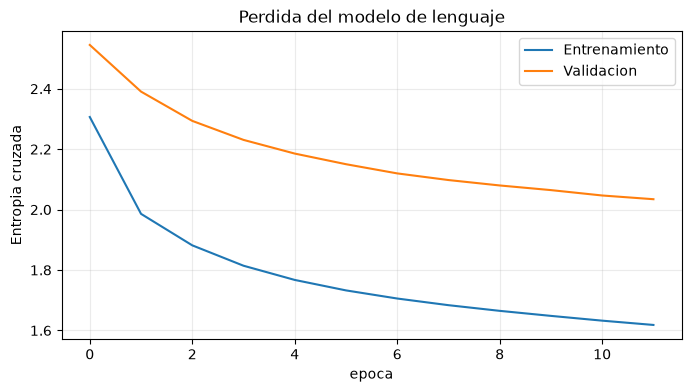

Perdida de validacion: 2.0344
Perplejidad de validacion: 7.65


In [7]:
# Graficamos la perdida de entrenamiento y validacion para observar convergencia y posible sobreajuste.
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validacion")
plt.xlabel("epoca")
plt.ylabel("Entropia cruzada")
plt.title("Perdida del modelo de lenguaje")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Calculamos e informamos la perplejidad final de validacion en escala interpretable.
val_loss = model.evaluate(X_val, y_val, verbose=0)
print(f"Perdida de validacion: {val_loss:.4f}")
print(f"Perplejidad de validacion: {np.exp(val_loss):.2f}")


La curva permite comparar el ajuste al tramo de entrenamiento con la capacidad de predecir el tramo retenido. Una perplejidad menor indica predicciones mas concentradas en los caracteres observados; como el vocabulario incluye puntuacion, espacios y letras acentuadas, su valor no debe compararse directamente con modelos tokenizados por palabras.


### 4. Funciones para generacion

Las funciones siguientes codifican un contexto, consultan la distribucion del siguiente caracter y lo agregan a la secuencia. Greedy selecciona siempre el caracter mas probable. Beam conserva varias continuaciones candidatas y acumula log-probabilidades para comparar secuencias completas.


In [8]:
# Convertimos texto a indices y reemplazamos caracteres desconocidos por espacios.
def encode_text(text):
    # El modelo se entreno en minuscula; limitamos el contexto a los ultimos caracteres disponibles.
    text = text.lower()
    return [char2idx.get(char, char2idx.get(" ", 0)) for char in text][-max_context_size:]

def next_char_probabilities(context_ids):
    # Predecimos el caracter siguiente usando solo los ultimos max_context_size indices.
    context_ids = context_ids[-max_context_size:]
    if not context_ids:
        context_ids = [char2idx.get(" ", 0)]
    # Completamos por la izquierda para respetar la longitud fija usada al entrenar.
    padded_context = [char2idx.get(" ", 0)] * (max_context_size - len(context_ids)) + context_ids
    prediction = model.predict(np.asarray([padded_context], dtype=np.int32), verbose=0)
    return prediction[0, -1, :]

def generate_greedy(seed_text, num_chars=200):
    # En greedy, cada iteracin agrega el caracter con maxima probabilidad.
    generated = encode_text(seed_text)
    for _ in range(num_chars):
        probabilities = next_char_probabilities(generated)
        generated.append(int(np.argmax(probabilities)))
    return "".join(idx2char[idx] for idx in generated)

def beam_search(seed_text, num_chars=200, num_beams=5, mode="det", temperature=1.0, seed=SEED):
    # Validamos los parametros para evitar distribuciones de muestreo invalidas.
    if num_beams < 1 or num_chars < 1:
        raise ValueError("num_beams y num_chars deben ser mayores que cero")
    if mode not in {"det", "sto"}:
        raise ValueError("mode debe ser 'det' (deterministico) o 'sto' (estocastico)")
    if temperature <= 0:
        raise ValueError("temperature debe ser mayor que cero")

    # Cada candidato almacena los indices generados y su log-probabilidad acumulada.
    rng = np.random.default_rng(seed)
    initial_context = encode_text(seed_text)
    beams = [(initial_context, 0.0)]

    # Expandimos cada candidato caracter por caracter y conservamos los mejores beams.
    for _ in range(num_chars):
        candidates = []
        for sequence, score in beams:
            probabilities = next_char_probabilities(sequence)
            # La temperatura ajusta cuan concentrada queda la distribucion antes de expandir.
            scaled_logits = np.log(np.maximum(probabilities, 1e-12)) / temperature
            scaled_logits -= np.max(scaled_logits)
            next_probs = np.exp(scaled_logits)
            next_probs /= next_probs.sum()
            log_probs = np.log(np.maximum(next_probs, 1e-12))

            if mode == "det":
                # Tomamos las opciones locales mas probables para la expansion deterministica.
                choices = np.argsort(log_probs)[-num_beams:]
            else:
                # Muestreamos opciones sin reemplazo segn su probabilidad para diversificar beams.
                choices = rng.choice(len(log_probs), size=min(num_beams, len(log_probs)),
                                     replace=False, p=next_probs)

            for char_idx in choices:
                candidates.append((sequence + [int(char_idx)], score + float(log_probs[char_idx])))

        # Ordenamos por puntuacion acumulada; en modo estocastico los candidatos tambien muestrean.
        beams = sorted(candidates, key=lambda item: item[1], reverse=True)[:num_beams]

    # Devolvemos todas las secuencias retenidas para poder inspeccionar alternativas.
    return ["".join(idx2char[idx] for idx in sequence) for sequence, _ in beams]


La busqueda de haz deterministica expande las opciones mas probables y devuelve las continuaciones con mayor log-probabilidad acumulada. En modo estocastico, la temperatura modifica cada distribucion antes del muestreo: valores bajos suelen concentrar las elecciones en los caracteres mas probables; valores altos dan mas oportunidad a alternativas. El resultado estocastico depende ademas de la semilla.


### 5. Comparacion de estrategias

Usamos el mismo contexto para comparar greedy, beam deterministico y beam estocastico. En los ejemplos estocasticos mantenemos fija la semilla para que se pueda reproducir la comparacion.


In [9]:
# Generamos continuaciones con las tres estrategias a partir del mismo contexto en espanol.
seed_text = "en un lugar "
print("GREEDY:")
print(generate_greedy(seed_text, num_chars=200))

print("\nBEAM DETERMINISTICO (5 alternativas):")
for idx, sequence in enumerate(beam_search(seed_text, num_chars=200, num_beams=5, mode="det"), start=1):
    print(f"{idx}. {sequence}")

# Comparamos dos temperaturas en la busqueda de haz estocastica con la misma semilla.
for temperature in (0.6, 1.0, 1.4):
    stochastic_sequences = beam_search(
        seed_text, num_chars=200, num_beams=5, mode="sto",
        temperature=temperature, seed=SEED,
    )
    print(f"\nBEAM ESTOCASTICO, temperatura={temperature}:")
    print(stochastic_sequences[0])


GREEDY:
en un lugar de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la caballero de la ca

BEAM DETERMINISTICO (5 alternativas):
1. en un lugar de los dios de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros que los 
2. en un lugar de los dios de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los d
3. en un lugar de los dios de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los caballeros de los m
4. en un lugar de los dios de los caballeros de los caballeros de los caballeros de los caba

### Interpretacion y conclusiones

Greedy suele producir una continuacion estable, pero al reutilizar siempre la opcion de maxima probabilidad puede repetir patrones locales. Beam deterministico compara varias rutas y suele preferir secuencias globalmente mas probables, aunque eso tampoco garantiza diversidad. Beam estocastico introduce variacion; al aumentar la temperatura se aplana la distribucion y aparecen elecciones menos probables, por lo que puede ganar diversidad y tambien coherencia puede disminuir.

La perdida y perplejidad de validacion cuantifican prediccion de caracteres en una particion cronologica; la generacion es una inspeccin cualitativa. Con tres obras literarias y un modelo pequeo, las frases no deben interpretarse como texto factual ni como espanol general. Las salidas concretas dependen del corpus, entrenamiento y version de las librerias.
